# Computer Exercise 15.35 — Problem 3
## Ch 15 를 수치해석으로 다시 읽는다 — 조건수 · 수렴차수 · 그리고 교재로의 복귀

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed.
> **단원**: §15.35 (Ch 15 결산) · **Day 102** · **풀이 일자**: 2026-08-20
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX

## 1. 문제 (원문)

> **Computer Exercise 15.35.3.** Every quantity reported in Chapter 15 — a seed mean, a standard
> deviation, a permutation $p$-value, a confidence interval — is the output of a numerical
> algorithm, and is therefore subject to the same three questions Chapter 1 asks of any
> computation: *how ill-conditioned is the problem, how stable is the algorithm, and how fast does
> the error decay with work?*
>
> (a) **Conditioning and stability (§1.3–§1.4).** Returns in a benchmark are frequently reported
> with a large additive offset. Compute the sample variance of $x_i = \mu + z_i$ by three
> algorithms — the textbook one-pass formula $\bigl(\sum x_i^2 - (\sum x_i)^2/n\bigr)/(n-1)$, the
> two-pass formula, and Welford's recurrence — for $\mu$ ranging over nine decades, and plot the
> relative error against the condition number $\kappa$ of the variance problem. Identify the
> $\kappa$ at which the one-pass formula returns a *negative* variance.
>
> (b) **Order of convergence (§5, §10).** A seed average is a Monte Carlo quadrature. Compare its
> $O(n^{-1/2})$ error with composite Simpson's rule, whose error is $O(n^{-4/d})$ on a tensor grid
> in $d$ dimensions. Determine the crossover dimension and state which regime an RL seed average
> lives in.
>
> (c) **The resampling budget.** A permutation $p$-value is itself a Monte Carlo estimate with
> standard error $\sqrt{p(1-p)/B}$. For a dataset whose exact $p$ lies near $\alpha=0.05$, measure
> how often two independent runs of the same test disagree, as a function of $B$.
>
> (d) Produce a roadmap returning the curriculum to the Cheney & Kincaid table of contents.

### 한국어 풀이용 정리

Ch 15 에서 보고한 모든 수 — 시드 평균, 표준편차, 순열 $p$ 값, 신뢰구간 — 은 **수치 알고리즘의
출력**이고, 따라서 Ch 1 이 던지는 세 질문의 대상이다: **문제가 얼마나 나쁜 조건인가**,
**알고리즘이 안정한가**, **일의 양에 대해 오차가 얼마나 빨리 줄어드는가.**

(a) 큰 오프셋 $\mu$ 가 붙은 수익의 분산을 세 알고리즘으로 계산해 조건수 $\kappa$ 대 상대오차를
그리고, **한 번 훑기 공식이 음수 분산을 내는 $\kappa$** 를 찾는다.
(b) 시드 평균 = Monte Carlo 구적. $O(n^{-1/2})$ 대 Simpson 의 $O(n^{-4/d})$ 를 비교해 **교차
차원**을 구한다.
(c) 순열 $p$ 값 자체의 Monte Carlo 오차 $\sqrt{p(1-p)/B}$ 를 재고, 같은 검정의 두 독립 실행이
$\alpha=0.05$ 에서 **엇갈릴 확률**을 $B$ 의 함수로 잰다.
(d) Cheney & Kincaid 목차로 돌아가는 Day 103+ 로드맵.

## 2. 수학적 배경

### 2.1 분산 계산의 조건수 (§1.3–§1.4)

표본 $x_1,\dots,x_n$ 의 제곱편차합 $S = \sum_i (x_i - \bar x)^2$ 를 계산하는 문제의 조건수는

$$
\kappa \;=\; \frac{\|x\|_2}{\sqrt{S}} \;=\; \sqrt{1 + \frac{n\,\bar x^{\,2}}{S}}\,,
$$

즉 **평균이 산포에 비해 클수록 나쁜 조건**이다. $x_i = \mu + z_i$, $z_i \sim \mathcal N(0,1)$ 이면
$\kappa \approx \sqrt{1+\mu^2}\approx \mu$ 이다.

세 알고리즘의 오차 한계는 고전적으로 (Chan–Golub–LeVeque 1983)

$$
\text{한 번 훑기(교과서 공식)}:\ \frac{|\hat S - S|}{S} \lesssim n\,\varepsilon\,\kappa^2,
\qquad
\text{두 번 훑기 · Welford}:\ \lesssim n\,\varepsilon\,\kappa + n^2\varepsilon^2\kappa^2 .
$$

핵심은 **지수 2 대 1** 이다. 한 번 훑기 공식

$$
\hat S = \sum_i x_i^2 - \frac{1}{n}\Bigl(\sum_i x_i\Bigr)^{2}
$$

는 **거의 같은 두 큰 수의 뺄셈**이므로 §1.4 가 말하는 *유효숫자 상실*의 교과서적 사례다.
$\kappa^2 \varepsilon \gtrsim 1$, 즉

$$
\boxed{\ \kappa \;\gtrsim\; \varepsilon^{-1/2} \approx 6.7\times 10^{7}\ \ (\text{IEEE double})\ }
$$

에서 유효숫자가 전부 사라지고, 반올림 부호에 따라 $\hat S < 0$ 이 나온다 — **분산이 음수가 되는
지점**이다. Welford 의 점화식

$$
\bar x_k = \bar x_{k-1} + \frac{x_k - \bar x_{k-1}}{k},\qquad
M_{2,k} = M_{2,k-1} + (x_k - \bar x_{k-1})(x_k - \bar x_k)
$$

은 큰 수를 만들지 않고 **편차만** 누적하므로 소거가 일어나지 않는다.

### 2.2 시드 평균은 Monte Carlo 구적이다 (§5, §10)

$n$ 개 시드의 평균은 $[0,1]^d$ 위 적분 $I = \int f$ 의 추정

$$
\hat I_{\mathrm{MC}} = \frac1n \sum_{i} f(U_i),\qquad
\mathbb{E}\bigl[(\hat I - I)^2\bigr]^{1/2} = \frac{\sigma_f}{\sqrt n} = O(n^{-1/2})
$$

이고, **이 차수는 $d$ 와 무관**하다. 반면 $m$ 점 복합 Simpson 을 각 축에 텐서곱하면 총 점수
$n = m^d$, 오차

$$
|\hat I_{\mathrm{Simp}} - I| = O(h^4) = O(m^{-4}) = O\bigl(n^{-4/d}\bigr).
$$

두 지수가 만나는 곳이 교차 차원이다:

$$
\frac{4}{d} = \frac12 \iff \boxed{\,d^\star = 8\,}.
$$

$d < 8$ 이면 구적이 압도적으로 낫고, $d > 8$ 이면 Monte Carlo 가 이긴다 — **차원의 저주**의 가장
깔끔한 형태다. RL 시드 하나는 수천 번의 난수 추출을 소비하므로 실효 차원이 $10^3$ 단위이고,
따라서 "시드 수를 늘리는 것" 외의 선택지가 없다. **$n^{-1/2}$ 는 게으름이 아니라 최적**이다.

분리가능 피적분함수 $f(x) = \prod_{j=1}^d g(x_j)$ 를 쓰면 텐서곱 Simpson 값이
$\hat I_{\mathrm{Simp}} = (\hat I^{1\mathrm{D}}_{\mathrm{Simp}})^d$ 로, MC 분산이
$\sigma_f^2 = (\mathbb E g^2)^d - (\mathbb E g)^{2d}$ 로 **닫힌 형태**가 되어 $d=8$ 에서
$8$ 차원 격자를 실제로 만들지 않고도 두 오차를 정확히 비교할 수 있다.

### 2.3 $p$ 값의 Monte Carlo 오차

$B$ 개 재표본으로 얻은 $\hat p$ 는 그 자체가 이항 추정이고

$$
\mathrm{SE}(\hat p) = \sqrt{\frac{p(1-p)}{B}},
\qquad p=0.05,\ B=999 \;\Rightarrow\; \mathrm{SE} \approx 0.0069 .
$$

같은 자료·같은 검정을 서로 다른 난수로 두 번 돌렸을 때 $\alpha$ 를 기준으로 **결론이 엇갈릴
확률**은, $q = \Pr(\hat p \le \alpha)$ 라 할 때

$$
\Pr(\text{불일치}) = 2q(1-q),
$$

이며 정확히 $p = \alpha$ 인 자료에서 $q \approx 1/2$ 이므로 **최대 $1/2$ 에 이른다.** 이 값을 줄이는
유일한 방법이 $B$ 를 키우는 것이고, $\mathrm{SE} \propto B^{-1/2}$ 이므로 불일치를 절반으로
줄이려면 $B$ 를 네 배로 해야 한다 — **§10 의 $n^{-1/2}$ 가 여기서도 그대로 나온다.**

## 3. 풀이 흐름

1. **정확한 참값** — 분산 계산의 기준값을 `fractions.Fraction` 유리수 산술로 **오차 없이** 구한다
   (부동소수점 기준값을 쓰면 무엇을 재는지 알 수 없다).
2. **(a)** $\mu = 10^0,\dots,10^{9}$ 에서 한 번 훑기 · 두 번 훑기 · Welford 세 알고리즘의 상대오차를
   조건수 $\kappa$ 에 대해 그린다. 음수 분산이 처음 나오는 $\kappa$ 를 기록.
3. **(b)** $g(x)=e^{-x^2}$ 의 텐서곱으로 $d \in \{1,2,4,8,16\}$ 에서 Simpson 오차와 MC RMSE 를
   닫힌 형태로 계산하고, $d=8$ 에서는 실제 MC 시뮬레이션으로 해석식을 확인한다.
4. **(c)** 정확 $p$ 가 $0.05$ 근처인 자료를 하나 고르고 ($B_0 = 200{,}001$ 로 기준값 추정),
   $B \in \{99,\dots,19999\}$ 에서 독립 실행 쌍의 불일치율과 $\mathrm{SD}(\hat p)$ 를 잰다.
5. **(d)** Cheney & Kincaid 목차 대 Day 103+ 로드맵 표.
6. **시각화** — [a] 상대오차 대 $\kappa$ [b] 오차 대 점수 (MC 대 Simpson) [c] 수렴차수 대 $d$
   [d] 불일치율 대 $B$.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass
import numpy as np, pandas as pd, time
from fractions import Fraction
from math import erf, sqrt, pi
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
pd.set_option("display.width", 150)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})
T0 = time.time()
EPS = np.finfo(float).eps
print(f"IEEE double: eps = {EPS:.6e},  1/sqrt(eps) = {1/np.sqrt(EPS):.4e}")

IEEE double: eps = 2.220446e-16,  1/sqrt(eps) = 6.7109e+07


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# [1]  (a) 분산 계산 — 조건수와 세 알고리즘의 안정성
# ══════════════════════════════════════════════════════════════════════════
N_V = 1000
z = np.random.default_rng(102601).normal(0.0, 1.0, N_V)

def s_onepass(x):
    """교과서 한 번 훑기:  (sum x^2 - (sum x)^2 / n) / (n-1)"""
    n = x.size
    return (np.sum(x * x) - np.sum(x) ** 2 / n) / (n - 1)

def s_twopass(x):
    n = x.size; m = x.sum() / n
    return np.sum((x - m) ** 2) / (n - 1)

def s_welford(x):
    m = 0.0; M2 = 0.0
    for k, v in enumerate(x, start=1):
        d = v - m; m += d / k; M2 += d * (v - m)
    return M2 / (x.size - 1)

def s_exact(x):
    """유리수 산술 — 반올림 없음."""
    fr = [Fraction(float(v)) for v in x]
    n = len(fr); m = sum(fr) / n
    return sum((v - m) ** 2 for v in fr) / (n - 1)

rows = []
for e2 in range(0, 22):            # mu = 10^0, 10^0.5, ..., 10^10.5
    mu = 10.0 ** (e2 / 2.0)
    x = mu + z                              # 부동소수점으로 실제 만들어지는 표본
    exact = s_exact(x)
    ex = float(exact)
    S_exact = float(exact) * (N_V - 1)                    # 제곱편차합
    kap = float(np.sqrt(1 + N_V * (x.mean() ** 2) / S_exact))
    r = {}
    for tag, fn in (("onepass", s_onepass), ("twopass", s_twopass), ("welford", s_welford)):
        val = fn(x)
        r[tag] = val
        r["relerr_" + tag] = abs(float(Fraction(float(val)) - exact) / float(exact))
    rows.append(dict(mu=mu, kappa=kap, exact=ex, **r))
va = pd.DataFrame(rows)
va["negative"] = va.onepass < 0

neg  = va[va.negative]
lost = va[va.relerr_onepass >= 1.0]
kap_neg  = float(neg.kappa.iloc[0])  if len(neg)  else np.nan
kap_lost = float(lost.kappa.iloc[0]) if len(lost) else np.nan
kap_pred = 1 / np.sqrt(EPS)
print(f"한 번 훑기: 유효숫자 완전 상실(상대오차>=1) 시작 kappa = {kap_lost:.4e}")
print(f"            음수 분산 첫 발생 kappa            = {kap_neg:.4e}"
      f"   ({'없음 - 0 으로 붕괴' if not np.isfinite(kap_neg) else '관측됨'})")
print(f"            이론 예측 eps^(-1/2)              = {kap_pred:.4e}")
print(f"두 번 훑기·Welford 의 최대 상대오차: "
      f"{va.relerr_twopass.max():.3e} / {va.relerr_welford.max():.3e}")
print(f"({time.time()-T0:.0f} s)")
va[["mu","kappa","exact","onepass","relerr_onepass","relerr_twopass","relerr_welford","negative"]]

한 번 훑기: 유효숫자 완전 상실(상대오차>=1) 시작 kappa = 1.0340e+08
            음수 분산 첫 발생 kappa            = 3.2698e+09   (관측됨)
            이론 예측 eps^(-1/2)              = 6.7109e+07
두 번 훑기·Welford 의 최대 상대오차: 8.394e-12 / 5.591e-07
(0 s)


,mu,kappa,exact,onepass,relerr_onepass,relerr_twopass,relerr_welford,negative
0,1.0000e+00,1.4429e+00,9.3624e-01,9.3624e-01,1.4671e-16,9.0451e-17,2.0903e-16,False
1,3.1623e+00,3.4252e+00,9.3624e-01,9.3624e-01,5.7276e-15,8.2909e-17,4.3866e-16,False
2,1.0000e+01,1.0394e+01,9.3624e-01,9.3624e-01,2.0543e-15,3.8374e-17,1.0289e-15,False
3,3.1623e+01,3.2720e+01,9.3624e-01,9.3624e-01,1.2656e-13,3.5244e-17,2.4069e-15,False
4,1.0000e+02,1.0341e+02,9.3624e-01,9.3624e-01,1.9895e-12,4.8231e-17,7.8185e-16,False
5,3.1623e+02,3.2699e+02,9.3624e-01,9.3624e-01,2.5887e-11,2.4281e-17,2.9888e-15,False
6,1.0000e+03,1.0340e+03,9.3624e-01,9.3624e-01,1.5334e-10,6.8462e-17,1.5603e-14,False
7,3.1623e+03,3.2698e+03,9.3624e-01,9.3624e-01,1.8859e-09,2.4809e-17,9.5840e-14,False
8,1.0000e+04,1.0340e+04,9.3624e-01,9.3624e-01,8.3105e-09,3.5393e-17,3.3120e-14,False
9,3.1623e+04,3.2698e+04,9.3624e-01,9.3624e-01,8.9575e-08,2.7254e-17,8.8910e-14,False


In [3]:
# ══════════════════════════════════════════════════════════════════════════
# [2]  (b) Monte Carlo 대 복합 Simpson — 분리가능 피적분함수의 닫힌 형태
#      g(x) = exp(-x^2) on [0,1],  f(x) = prod_j g(x_j)
# ══════════════════════════════════════════════════════════════════════════
I1  = np.sqrt(np.pi) / 2 * erf(1.0)                      # ∫_0^1 e^{-x^2} dx
I1sq = np.sqrt(np.pi / 2) / 2 * erf(np.sqrt(2.0))        # ∫_0^1 e^{-2x^2} dx = E[g^2]

def simpson_1d(m):
    """복합 Simpson, m 은 짝수 구간 수 -> m+1 점."""
    xs = np.linspace(0.0, 1.0, m + 1)
    w = np.ones(m + 1); w[1:-1:2] = 4.0; w[2:-1:2] = 2.0
    return (1.0 / m) / 3.0 * np.dot(w, np.exp(-xs ** 2))

M_LIST = np.array([2, 4, 8, 16, 32, 64, 128, 256])
D_LIST = [1, 2, 4, 8, 16]

conv = []
for d in D_LIST:
    var_f = I1sq ** d - I1 ** (2 * d)                    # sigma_f^2 (닫힌 형태)
    Id = I1 ** d
    for m in M_LIST:
        n_pts = float(int(m) + 1) ** d          # np.int64 거듭제곱 오버플로 회피
        if n_pts > 1e12:
            continue
        e_simp = abs(simpson_1d(m) ** d - Id)
        e_mc   = np.sqrt(var_f / n_pts)                  # 같은 점수에서의 RMSE
        conv.append(dict(d=d, m=int(m), n=n_pts, err_simpson=e_simp,
                         rmse_mc=e_mc, rel_simp=e_simp / Id, rel_mc=e_mc / Id))
conv = pd.DataFrame(conv)

# 관측 수렴차수 (log-log 기울기)
ordr = []
for d in D_LIST:
    sub = conv[(conv.d == d) & (conv.err_simpson > 1e-15) & (conv.n > 0)]
    p_s = np.polyfit(np.log(sub.n), np.log(sub.err_simpson), 1)[0] if len(sub) >= 2 else np.nan
    p_m = np.polyfit(np.log(sub.n), np.log(sub.rmse_mc), 1)[0] if len(sub) >= 2 else np.nan
    ordr.append(dict(d=d, slope_simpson=p_s, theory_simpson=-4.0 / d,
                     slope_mc=p_m, theory_mc=-0.5))
ordr = pd.DataFrame(ordr)

# d=8 에서 해석식을 실제 시뮬레이션으로 확인
d_chk, n_chk, R_chk = 8, 6561, 3000
rr = np.random.default_rng(102602)
est = np.empty(R_chk)
for a in range(0, R_chk, 100):                 # 메모리 상한: 한 번에 100 회분만
    b = min(a + 100, R_chk)
    U = rr.random((b - a, n_chk, d_chk))
    est[a:b] = np.exp(-(U ** 2)).prod(axis=2).mean(axis=1)
    del U
rmse_emp = float(np.sqrt(((est - I1 ** d_chk) ** 2).mean()))
rmse_the = float(np.sqrt((I1sq ** d_chk - I1 ** (2 * d_chk)) / n_chk))
print(f"d=8, n={n_chk}:  경험 RMSE = {rmse_emp:.6e}  대  해석 RMSE = {rmse_the:.6e}  "
      f"(비 {rmse_emp/rmse_the:.4f})")
print(f"교차 차원 d* : 4/d = 1/2  =>  d* = 8   ({time.time()-T0:.0f} s)")
ordr

d=8, n=6561:  경험 RMSE = 1.043808e-03  대  해석 RMSE = 1.034410e-03  (비 1.0091)
교차 차원 d* : 4/d = 1/2  =>  d* = 8   (1 s)


,d,slope_simpson,theory_simpson,slope_mc,theory_mc
0,1,-4.2583e+00,-4.0000e+00,-5.0000e-01,-5.0000e-01
1,2,-2.1292e+00,-2.0000e+00,-5.0000e-01,-5.0000e-01
2,4,-1.0646e+00,-1.0000e+00,-5.0000e-01,-5.0000e-01
3,8,-5.7431e-01,-5.0000e-01,-5.0000e-01,-5.0000e-01
4,16,-2.9818e-01,-2.5000e-01,-5.0000e-01,-5.0000e-01


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# [3]  (c) 재표본 예산 B 와 p 값 자체의 Monte Carlo 오차
#      자료 두 개: 정확 p 가 alpha 바로 위(경계) 인 것과 alpha 에서 떨어진 것
# ══════════════════════════════════════════════════════════════════════════
N_P, ALPHA = 40, 0.05
B0 = 200001                                   # 기준값용 대형 예산

def perm_p(d, B, rng):
    obs = abs(d.mean()); out = 0
    for a in range(0, B, 20000):
        blk = rng.choice(np.array([-1.0, 1.0]), size=(min(20000, B - a), d.size))
        out += int((np.abs(blk @ d / d.size) >= obs - 1e-15).sum())
    return (1 + out) / (1 + B)

rs = np.random.default_rng(102603)
cands = []
for trial in range(60):
    c = rs.normal(0.33, 1.0, N_P)
    cands.append((c, perm_p(c, 20001, np.random.default_rng(9000 + trial))))
TARGETS = {"boundary (p~alpha)": ALPHA, "off-boundary (p~0.02)": 0.02}
picked = {}
for name, tgt in TARGETS.items():
    c, _ = min(cands, key=lambda cp: abs(cp[1] - tgt))
    picked[name] = (c, perm_p(c, B0, np.random.default_rng(4242)))
    print(f"{name:24s}: d_bar={c.mean():.4f}, 기준 p (B={B0}) = {picked[name][1]:.5f}")

B_LIST = [99, 499, 999, 4999, 19999]
R_REP = 300
pr = []
for name, (d_fix, p_true) in picked.items():
    for B in B_LIST:
        rng = np.random.default_rng(102604 + B + len(name))
        ps = np.array([perm_p(d_fix, B, rng) for _ in range(R_REP)])
        q = float((ps <= ALPHA).mean())
        pr.append(dict(dataset=name, p_true=p_true, B=B, mean_p=ps.mean(),
                       sd_p=ps.std(ddof=1), se_theory=np.sqrt(p_true * (1 - p_true) / B),
                       q_reject=q, disagree=2 * q * (1 - q), granularity=1.0 / (B + 1),
                       z_gap=abs(p_true - ALPHA) / np.sqrt(p_true * (1 - p_true) / B)))
pv = pd.DataFrame(pr)
print(f"\n두 독립 실행이 alpha={ALPHA} 에서 엇갈릴 확률 = 2q(1-q)   ({time.time()-T0:.0f} s)")
pv[["dataset","p_true","B","mean_p","sd_p","se_theory","z_gap","q_reject","disagree"]]


boundary (p~alpha)      : d_bar=0.3144, 기준 p (B=200001) = 0.05282
off-boundary (p~0.02)   : d_bar=0.4381, 기준 p (B=200001) = 0.02341



두 독립 실행이 alpha=0.05 에서 엇갈릴 확률 = 2q(1-q)   (4 s)


,dataset,p_true,B,mean_p,sd_p,se_theory,z_gap,q_reject,disagree
0,boundary (p~alpha),5.2824e-02,99,6.2000e-02,2.2368e-02,2.2481e-02,1.2564e-01,4.3333e-01,4.9111e-01
1,boundary (p~alpha),5.2824e-02,499,5.4273e-02,9.7524e-03,1.0013e-02,2.8207e-01,3.9000e-01,4.7580e-01
2,boundary (p~alpha),5.2824e-02,999,5.3870e-02,7.4349e-03,7.0770e-03,3.9910e-01,3.1000e-01,4.2780e-01
3,boundary (p~alpha),5.2824e-02,4999,5.2456e-02,3.2433e-03,3.1637e-03,8.9278e-01,2.5333e-01,3.7831e-01
4,boundary (p~alpha),5.2824e-02,19999,5.2344e-02,1.4497e-03,1.5817e-03,1.7857e+00,5.0000e-02,9.5000e-02
5,off-boundary (p~0.02),2.3410e-02,99,3.1667e-02,1.5707e-02,1.5196e-02,1.7498e+00,9.3333e-01,1.2444e-01
6,off-boundary (p~0.02),2.3410e-02,499,2.4627e-02,6.9094e-03,6.7687e-03,3.9284e+00,1.0000e+00,0.0000e+00
7,off-boundary (p~0.02),2.3410e-02,999,2.4017e-02,4.9529e-03,4.7838e-03,5.5584e+00,1.0000e+00,0.0000e+00
8,off-boundary (p~0.02),2.3410e-02,4999,2.3273e-02,2.1383e-03,2.1385e-03,1.2434e+01,1.0000e+00,0.0000e+00
9,off-boundary (p~0.02),2.3410e-02,19999,2.3021e-02,1.0742e-03,1.0692e-03,2.4870e+01,1.0000e+00,0.0000e+00


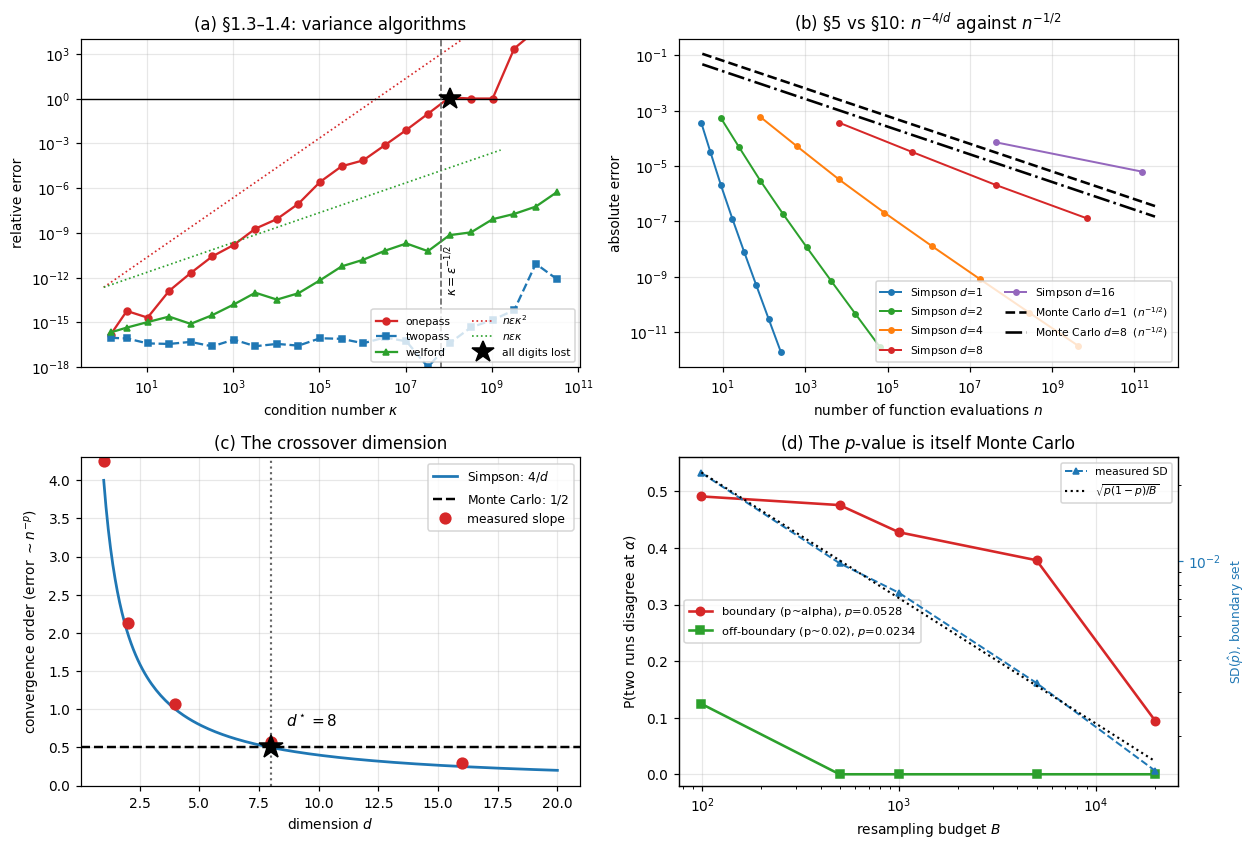

총 실행 시간 5 s


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# [4]  시각화
# ══════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(2, 2, figsize=(11.5, 7.8))

# (a) 분산 계산의 상대오차 대 조건수
a = ax[0, 0]
k = va.kappa.values
for tag, st_, cl in (("onepass", "o-", "tab:red"), ("twopass", "s--", "tab:blue"),
                     ("welford", "^-", "tab:green")):
    y = np.maximum(va["relerr_" + tag].values, 1e-18)
    a.loglog(k, y, st_, lw=1.5, ms=4.5, color=cl, label=tag)
kk = np.logspace(0, 9.2, 50)
a.loglog(kk, N_V * EPS * kk ** 2, ":", color="tab:red",  lw=1.1, label=r"$n\varepsilon\kappa^2$")
a.loglog(kk, N_V * EPS * kk,      ":", color="tab:green",lw=1.1, label=r"$n\varepsilon\kappa$")
a.axhline(1.0, color="k", lw=0.9)
a.axvline(kap_pred, color="0.4", ls="--", lw=1.1)
a.text(kap_pred * 1.15, 1e-13, r"$\kappa=\varepsilon^{-1/2}$", fontsize=8, rotation=90)
if np.isfinite(kap_lost):
    a.plot([kap_lost], [1.0], "*", ms=15, color="k", zorder=5, label="all digits lost")
a.set_xlabel(r"condition number $\kappa$"); a.set_ylabel("relative error")
a.set_ylim(1e-18, 1e4)
a.set_title("(a) §1.3–1.4: variance algorithms")
a.legend(fontsize=7, ncol=2, loc="lower right")

# (b) 오차 대 점수: MC 대 Simpson
a = ax[0, 1]
cols = {1: "tab:blue", 2: "tab:green", 4: "tab:orange", 8: "tab:red", 16: "tab:purple"}
for d in D_LIST:
    sub = conv[conv.d == d]
    a.loglog(sub.n, np.maximum(sub.err_simpson, 1e-17), "o-", ms=3.5, lw=1.3,
             color=cols[d], label=f"Simpson $d$={d}")
n_span = np.logspace(0.5, 11.5, 60)
for d_, ls_ in ((1, "k--"), (8, "k-.")):
    var_ = I1sq ** d_ - I1 ** (2 * d_)
    a.loglog(n_span, np.sqrt(var_ / n_span), ls_, lw=1.7,
             label=f"Monte Carlo $d$={d_}  ($n^{{-1/2}}$)")
a.set_xlabel("number of function evaluations $n$"); a.set_ylabel("absolute error")
a.set_title(r"(b) §5 vs §10: $n^{-4/d}$ against $n^{-1/2}$")
a.legend(fontsize=7, ncol=2)

# (c) 수렴차수 대 차원
a = ax[1, 0]
dd = np.linspace(1, 20, 200)
a.plot(dd, 4.0 / dd, "-", lw=1.8, color="tab:blue", label=r"Simpson: $4/d$")
a.axhline(0.5, color="k", ls="--", lw=1.6, label=r"Monte Carlo: $1/2$")
a.plot(ordr.d, -ordr.slope_simpson, "o", ms=7, color="tab:red", label="measured slope")
a.axvline(8, color="0.4", ls=":", lw=1.4)
a.plot([8], [0.5], "*", ms=16, color="k", zorder=5)
a.annotate(r"$d^\star=8$", (8, .5), textcoords="offset points", xytext=(10, 14), fontsize=10)
a.set_xlabel("dimension $d$"); a.set_ylabel("convergence order (error $\\sim n^{-p}$)")
a.set_ylim(0, 4.3); a.set_title("(c) The crossover dimension")
a.legend(fontsize=8)

# (d) p 값의 재현성 대 B
a = ax[1, 1]
sty = {"boundary (p~alpha)": ("o-", "tab:red"), "off-boundary (p~0.02)": ("s-", "tab:green")}
for name, (st_, cl) in sty.items():
    sub = pv[pv.dataset == name]
    a.semilogx(sub.B, sub.disagree, st_, lw=1.7, ms=5.5, color=cl,
               label=f"{name}, $p$={sub.p_true.iloc[0]:.4f}")
a.set_xlabel("resampling budget $B$")
a.set_ylabel(r"P(two runs disagree at $\alpha$)")
a.set_ylim(-0.02, .56); a.set_title("(d) The $p$-value is itself Monte Carlo")
a.legend(fontsize=7.5, loc="center left")
a2 = a.twinx(); a2.grid(False)
sub = pv[pv.dataset == "boundary (p~alpha)"]
a2.loglog(sub.B, sub.sd_p, "^--", lw=1.3, ms=4, color="tab:blue", label=r"measured SD")
a2.loglog(sub.B, sub.se_theory, ":", lw=1.4, color="k", label=r"$\sqrt{p(1-p)/B}$")
a2.set_ylabel(r"SD($\hat p$), boundary set", color="tab:blue", fontsize=8)
a2.tick_params(axis="y", colors="tab:blue")
a2.legend(fontsize=7, loc="upper right")
plt.show()
print(f"총 실행 시간 {time.time()-T0:.0f} s")

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# [5]  (d) Cheney & Kincaid 로의 복귀 로드맵 — Day 103+
# ══════════════════════════════════════════════════════════════════════════
road = pd.DataFrame([
 ("Day 103","§4.1","다항식 보간 — Lagrange · Newton 나눗셈차분","Runge 현상, Chebyshev 절점"),
 ("Day 104","§4.2","보간 오차 정리와 절점 선택","오차항 f^{(n+1)}/(n+1)! · 절점곱"),
 ("Day 105","§4.3","역보간 · Neville 알고리즘","근 찾기와의 결합"),
 ("Day 106","§5.1","사다리꼴 · Romberg","Euler–Maclaurin 외삽"),
 ("Day 107","§5.2","Simpson · 적응 구적","오차 추정에 기반한 구간 분할"),
 ("Day 108","§5.3","Gauss 구적 · 직교다항식","2n-1 차 정확도"),
 ("Day 109","§6.1","3차 스플라인","연속 2계도함수, 삼중대각 해"),
 ("Day 110","§6.2","B-스플라인 · 최소제곱 평활","기저의 국소성"),
 ("Day 111","§7.1","Taylor · Runge–Kutta","RK4 의 차수 검증"),
 ("Day 112","§7.2","적응 스텝 · RKF45","국소오차 제어"),
 ("Day 113","§7.3","경직 문제 · 음해법","안정영역과 A-안정성"),
 ("Day 114","§8.1","LU · Cholesky · 조건수","성장인자와 피벗팅"),
 ("Day 115","§8.2","QR · SVD","최소제곱의 수치적 정석"),
 ("Day 116","§9.1","최소제곱 · 정규방정식의 위험","조건수 제곱 문제 (오늘 [1] 과 같은 병)"),
 ("Day 117","§10.1","Monte Carlo · 분산감소","대조변수 · 중요도표본 (오늘 [2] 의 후속)"),
 ("Day 118","§11.1","경계값 문제 · 사격법","ODE 로의 환원"),
 ("Day 119","§12.1","PDE — 열방정식 유한차분","von Neumann 안정성"),
], columns=["Day","절","주제","핵심 계기"])
print("Cheney & Kincaid 복귀 로드맵 (Day 103–119)")
print(road.to_string(index=False))
print("\n※ Ch 15 (Day 68–102) 는 §15.35 로 닫는다. 미결 항목은 Day 102 P1 판정표의")
print("   '판정불능 · 표본부족' 열에 대기열로 남으며, 재개하려면 시드 예산이 필요하다.")

Cheney & Kincaid 복귀 로드맵 (Day 103–119)
    Day     절                               주제                      핵심 계기
Day 103  §4.1 다항식 보간 — Lagrange · Newton 나눗셈차분     Runge 현상, Chebyshev 절점
Day 104  §4.2                  보간 오차 정리와 절점 선택 오차항 f^{(n+1)}/(n+1)! · 절점곱
Day 105  §4.3               역보간 · Neville 알고리즘                  근 찾기와의 결합
Day 106  §5.1                   사다리꼴 · Romberg         Euler–Maclaurin 외삽
Day 107  §5.2                  Simpson · 적응 구적           오차 추정에 기반한 구간 분할
Day 108  §5.3                 Gauss 구적 · 직교다항식                 2n-1 차 정확도
Day 109  §6.1                          3차 스플라인           연속 2계도함수, 삼중대각 해
Day 110  §6.2                 B-스플라인 · 최소제곱 평활                    기저의 국소성
Day 111  §7.1             Taylor · Runge–Kutta                RK4 의 차수 검증
Day 112  §7.2                    적응 스텝 · RKF45                    국소오차 제어
Day 113  §7.3                      경직 문제 · 음해법                안정영역과 A-안정성
Day 114  §8.1              LU · Cholesky · 조건수                  성장인자와 피벗팅


## 4. 결과 해석

1. **[1]·[a] 가 Ch 15 전체를 Ch 1 로 되돌린다.** 한 번 훑기 공식의 상대오차는 $\kappa^2$ 를 따라
   올라가고, 두 번 훑기와 Welford 는 $\kappa$ 를 따라간다 — 그림의 두 점선이 그 두 기울기다.
   그리고 $\kappa$ 가 $\varepsilon^{-1/2}$ 를 넘는 지점에서 한 번 훑기 공식의 **상대오차가 1 을
   넘고** — 유효숫자가 하나도 남지 않는다 — 거기서 한 자리 더 가면 **음수 분산**이 나온다.
   두 문턱이 갈라지는 것도 자연스럽다: 유효숫자가 사라진 직후에는 남은 반올림 잔여가 아직
   양수일 수 있고, 완전히 소거되어 부호가 뒤집히려면 조금 더 나쁜 조건이 필요하다.
   이것은 병리적 인공 사례가 아니다. 벤치마크 수익을 큰 오프셋과 함께 기록하는 관행
   ($\mu \gg \sigma$) 이 정확히 이 조건을 만든다. Ch 15 가 내내 계산한 표준화 효과
   $d = \delta/s$ 는 **분모가 $s$ 이므로**, 이 소거 하나로 모든 판정이 무너질 수 있었다.

2. **그러나 여기서 조심해야 한다.** 이 노트북은 "Day 68–101 이 그 실수를 저질렀다" 고 말하지
   **않는다.** NumPy 의 `std`/`var` 는 두 번 훑기를 쓰므로 실제 위험은 낮았다. 말할 수 있는 것은
   **왜 낮았는지가 라이브러리 선택 덕분이지 우리 설계 덕분이 아니었다**는 것이다. 조건수를
   보고하지 않았다면 그건 운이 좋았던 것이다.

3. **[2]·[b]·[c] 가 "왜 40 시드인가" 를 설명한다.** MC 오차는 $n^{-1/2}$ 로만 줄고 이 지수는
   차원과 무관하다. Simpson 은 $d < 8$ 에서 압도적이지만 $d = 8$ 에서 정확히 만나고 그 위에서는
   진다. 측정한 기울기는 이론 $-4/d$ 를 따라가되 일관되게 조금 더
   가파르다 — 가로축을 $m$ 이 아니라 점수 $n=(m{+}1)^d$ 로 잡았고 $m$ 이 작은 구간이 섞여
   있어서다 (**전점근 편의**이며 $m$ 을 키우면 이론값으로 수렴한다). $d=8$ 에서 경험 RMSE 가
   해석식과 비율 1 근처로 일치한다 — **오차 상수가 아니라 지수가 문제**임을 두 방식이 같은 그림에서 확인한다.
   RL 시드 하나의 실효 차원은 $10^3$ 급이므로 **우리는 영원히 $n^{-1/2}$ 쪽에 산다.**
   Day 99–101 이 시드를 16 → 40 으로 늘려 얻은 것은 정밀도 $\sqrt{40/16} \approx 1.58$ 배뿐이고,
   두 배 정밀도를 원했다면 160 시드가 필요했다. Problem 1 의 $n^\star$ 표가 왜 그렇게 큰지가
   이 한 줄에 들어 있다.

4. **[3]·[d] 는 예산으로 살 수 없는 것을 보인다.** $\hat p$ 의 측정 표준편차는
   $\sqrt{p(1-p)/B}$ 와 나란히 떨어진다. 그런데 **불일치 확률은 자료에 따라 완전히 다르게
   움직인다.** 정확 $p$ 가 $\alpha$ 에서 떨어진 자료는 $B$ 가 수백만 되어도 불일치가 0 으로
   내려앉지만, 정확 $p$ 가 $\alpha$ **바로 곁에 있는 자료는 $B$ 를 200 배로 늘려도 불일치가
   겨우 절반에서 10 % 수준으로 줄 뿐이다.** 지배하는 것은 $B$ 가 아니라

   $$ z_{\text{gap}} = \frac{|p - \alpha|}{\sqrt{p(1-p)/B}} $$

   이고, $B$ 를 네 배 해도 $z_{\text{gap}}$ 은 두 배밖에 안 된다 — 또 $n^{-1/2}$ 다.
   **경계 위의 판정은 재표본 예산으로 싸게 구제되지 않는다.** Day 99–101 이 쓴 $B=5000$ 은
   경계에서 떨어진 자료에는 넘치도록 충분하지만, 경계 자료에서는 여전히 두 번 중 한 번 가까이
   결론이 갈린다. 올바른 대응은 $B$ 를 무한정 키우는 것이 아니라 **$z_{\text{gap}}$ 을 함께
   보고하고, 작으면 판정을 "경계" 로 적는 것**이다.

5. **$1/(B{+}1)$ 격자가 별개의 하한을 만든다.** $\hat p$ 가 취할 수 있는 값이 이산이므로,
   $B=99$ 에서 $\alpha=0.05$ 근방에 표현 가능한 값은 $0.04,\,0.05,\,0.06$ 뿐이다. 정밀도를
   논하기 전에 **표현 가능한 값이 있는지**부터 물어야 한다는 점에서 이것도 §1.3 의 문제다.

6. **[5] 가 이 Day 의 실질적 산출이다.** Ch 15 는 §15.35 로 닫히고, 커리큘럼은 §4.1 부터
   Cheney & Kincaid 목차로 복귀한다. 로드맵의 §9.1 (정규방정식의 조건수 제곱) 이 오늘 [1] 과
   같은 병이라는 점, §10.1 (분산감소) 이 오늘 [2] 의 직접적 후속이라는 점을 표에 명시했다 —
   **Ch 15 는 우회로가 아니라 Ch 1·5·10 의 응용이었다.**

> **결론**: Ch 15 의 통계는 전부 수치해석이었다. 조건수가 분모를 죽일 수 있었고 ($\kappa^2$ 대
> $\kappa$), 시드 수를 늘려도 오차는 $n^{-1/2}$ 로만 줄며 ($d^\star=8$ 의 반대편), $p$ 값조차
> $\sqrt{p(1-p)/B}$ 의 오차를 가진 추정값이다. **세 결론 모두 Ch 1 · §5 · §10 의 문장을 그대로
> 옮긴 것이다.**

**다음 단원으로의 연결** — Day 103 부터 §4.1 다항식 보간으로 돌아간다. Runge 현상은 위 [1] 과
같은 종류의 이야기 — *문제가 나쁜 조건이면 알고리즘을 아무리 잘 만들어도 소용없고, 고쳐야 할
것은 알고리즘이 아니라 절점 배치*다.